In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from tensorflow.python.feature_column.feature_column_v2 import numeric_column
from xgboost import XGBClassifier

In [2]:
data=pd.read_csv(r"C:\Users\ashis\OneDrive\Documents\Internship\Code Alpha Interndhip\ML Projects\Disease Prediction\Diabetes Prediction\diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

FEATURES = X.columns.tolist()
FEATURES

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [11]:
zero_invalid_cols = [
    "Glucose", "BloodPressure",
    "SkinThickness", "Insulin", "BMI"
]

X[zero_invalid_cols] = X[zero_invalid_cols].replace(0, np.nan)

In [13]:
X.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
from sklearn.metrics import confusion_matrix

In [40]:
y_pred=xgb.predict(X_test)
cm=confusion_matrix(y_test, y_pred)

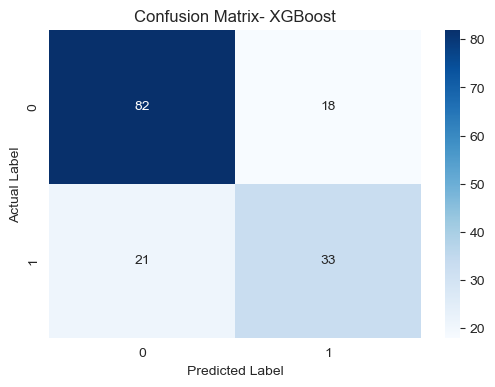

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix- XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

In [43]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rfc,
    "Decision Tree": dtc,
    "XGBoost": xgb
}

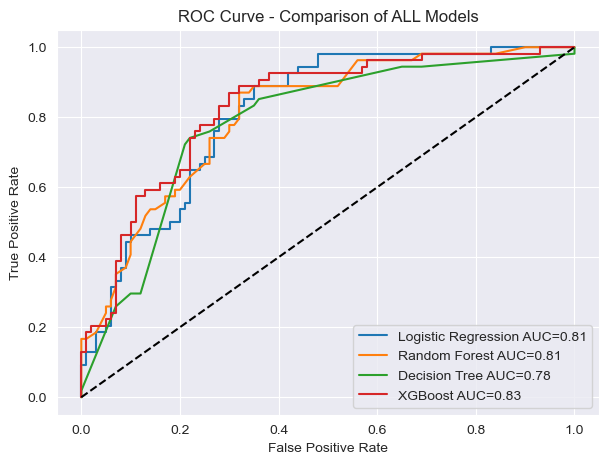

In [44]:
plt.figure(figsize=(7,5))
for name, model in models.items():
    y_proba=model.predict_proba(X_test)[:,1]
    fpr, tpr, _ =roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr,tpr, label=f"{name} AUC={auc_score:.2f}")

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Comparison of ALL Models')
plt.legend()
plt.show()

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [19]:
numeric_pipeline=Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
preprocessor=ColumnTransformer(transformers=[("num", numeric_pipeline, FEATURES)])

In [24]:
scale_pos_weight= len(y_train[y_train==0])/ len(y_train[y_train==1])
scale_pos_weight

1.8691588785046729

In [25]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [26]:
pipeline = Pipeline(steps=[("preprocess", preprocessor),("model", xgb_model)])

In [27]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_by...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [29]:
from sklearn.metrics import classification_report, roc_auc_score

In [30]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       100
           1       0.62      0.69      0.65        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

ROC-AUC: 0.8355555555555556


In [31]:
print("Min:", np.min(y_prob))
print("Max:", np.max(y_prob))
print("Mean:", np.mean(y_prob))

Min: 0.0016655417
Max: 0.98659164
Mean: 0.37850645


In [32]:
sample_non_diabetic = pd.DataFrame([[
    1, 85, 66, 29, 80, 26.6, 0.351, 31
]], columns=FEATURES)

probs = pipeline.predict_proba(sample_non_diabetic)[0]

print("Non-diabetic:", round(probs[0], 3))
print("Diabetic:", round(probs[1], 3))

Non-diabetic: 0.99
Diabetic: 0.01


In [33]:
sample_diabetic = pd.DataFrame([[
    4, 160, 88, 35, 250, 35.2, 0.672, 45
]], columns=FEATURES)

probs = pipeline.predict_proba(sample_diabetic)[0]

print("Non-diabetic:", round(probs[0], 3))
print("Diabetic:", round(probs[1], 3))

Non-diabetic: 0.088
Diabetic: 0.912


In [41]:
import joblib

In [35]:
thresholds = np.arange(0.3, 0.8, 0.05)

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    print(f"Threshold {t:.2f}")
    print(classification_report(y_test, preds))

Threshold 0.30
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       100
           1       0.60      0.80      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154

Threshold 0.35
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154

Threshold 0.40
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       100
           1       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      

In [37]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=pipeline,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocess',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['Pregnancies',
                                                                                    'Glucose',
                                                                                    'BloodPressure',
                                                                                    'SkinThickness',
                                                                                    'Insulin',
                                                                                    'BMI',
                                                                                    'DiabetesPedigreeFunction',
                                                                                    'Age'])])),
                                                 ('model',
                                                  XGBClassifier(base_score=None,
                                                                bo...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=4,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=300,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]),
                       method='isotonic')

In [38]:
joblib.dump(calibrated_model, "diabetes_xgboost_pipeline.joblib")

['diabetes_xgboost_pipeline.joblib']

In [39]:
test_input = pd.DataFrame([[
    1, 85, 66, 29, 80, 26.6, 0.351, 31
]], columns=FEATURES)

probs = calibrated_model.predict_proba(test_input)[0]

print("Non-diabetic:", round(probs[0], 3))
print("Diabetic:", round(probs[1], 3))

Non-diabetic: 0.958
Diabetic: 0.042
